In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import Sam2Processor, Sam2Model
from peft import LoraConfig, get_peft_model

# config
MODEL_ID = "facebook/sam2.1-hiera-tiny"
DATASET_ID = "RGarrido03/kvasir-seg-augmented"
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
EPOCHS = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#
# three data splits
dataset = load_dataset(DATASET_ID)
train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

processor = Sam2Processor.from_pretrained(MODEL_ID)
model = Sam2Model.from_pretrained(MODEL_ID)

# LoRA adaptor
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)
model = get_peft_model(model, lora_config)
model.to(DEVICE)

# b box provizoriu
def get_bounding_box(mask):
    """Extracts [xmin, ymin, xmax, ymax] as standard Python floats."""
    y_indices, x_indices = np.where(mask > 0)
    if len(x_indices) == 0:
        return [0.0, 0.0, 10.0, 10.0]
    return [
        float(np.min(x_indices)),
        float(np.min(y_indices)),
        float(np.max(x_indices)),
        float(np.max(y_indices))
    ]

def collate_fn(batch):
    images, masks, boxes = [], [], []
    for item in batch:
        img = item["image"].convert("RGB")
        mask = np.array(item["mask"].convert("L"))
        mask = (mask > 128).astype(np.uint8)

        box = get_bounding_box(mask)

        images.append(np.array(img))
        masks.append(mask)
        boxes.append([box]) # SAM2 [[box]] nesting

    inputs = processor(images, input_boxes=boxes, return_tensors="pt")
    inputs["ground_truth_masks"] = torch.from_numpy(np.array(masks)).unsqueeze(1)
    return inputs

def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return 1 - ((2. * intersection + smooth) / (union + smooth)).mean()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# training/ validation
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(DEVICE)
        input_boxes = batch["input_boxes"].to(DEVICE)
        gt_masks = batch["ground_truth_masks"].to(DEVICE).float()

        outputs = model(pixel_values=pixel_values, input_boxes=input_boxes, multimask_output=False)
        pred_masks = outputs.pred_masks.squeeze(2)

        loss = torch.nn.functional.binary_cross_entropy_with_logits(pred_masks, gt_masks) + dice_loss(pred_masks, gt_masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_boxes = batch["input_boxes"].to(DEVICE)
            gt_masks = batch["ground_truth_masks"].to(DEVICE).float()

            outputs = model(pixel_values=pixel_values, input_boxes=input_boxes, multimask_output=False)
            pred_masks = outputs.pred_masks.squeeze(2)

            v_loss = torch.nn.functional.binary_cross_entropy_with_logits(pred_masks, gt_masks) + dice_loss(pred_masks, gt_masks)
            val_loss += v_loss.item()

    print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

model.save_pretrained("sam2.1-kvasir-lora-final")


README.md:   0%|          | 0.00/822 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/412M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/51.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/51.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4800 [00:00<?, ? examples/s]

...

You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/156M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Epoch 1 [Val]: 100%|██████████| 150/150 [01:53<00:00,  1.32it/s]

Epoch 1 Summary: Train Loss: 0.1033 | Val Loss: 0.0867


In [ ]:
from peft import PeftModel
from transformers import Sam2Model

# Load sam2
base_model = Sam2Model.from_pretrained("facebook/sam2.1-hiera-tiny")

# LoRA adapter
model = PeftModel.from_pretrained(base_model, "sam2.1-kvasir-lora-final")

merged_model = model.merge_and_unload()

merged_model.save_pretrained("./sam2_kvasir_merged")
print("Model merged and saved successfully.")

You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model merged and saved successfully.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

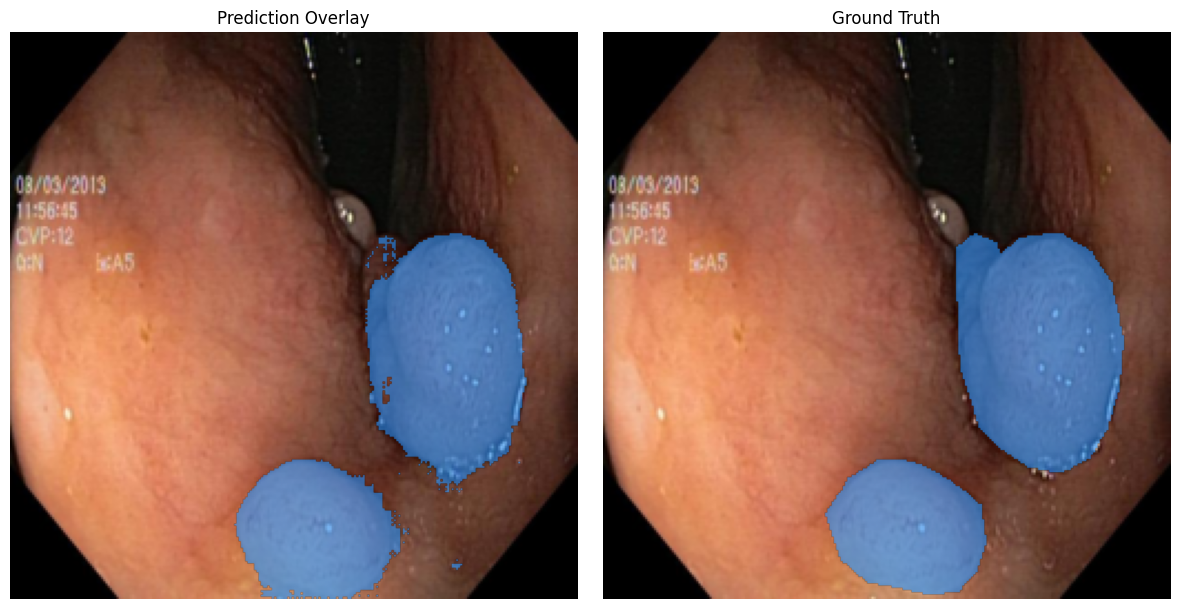

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import Sam2Processor, Sam2Model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./sam2_kvasir_merged"
processor = Sam2Processor.from_pretrained("facebook/sam2.1-hiera-tiny")
model = Sam2Model.from_pretrained(model_path).to(DEVICE)

# dataset trebuie sa fie rulat anterior
test_sample = dataset["test"][5]
image = test_sample["image"].convert("RGB")
ground_truth_mask = np.array(test_sample["mask"].convert("L"))

# Create Bounding Box Prompt (from GT mask for inference test)
y_indices, x_indices = np.where(ground_truth_mask > 0)
bbox = [float(np.min(x_indices)), float(np.min(y_indices)),
        float(np.max(x_indices)), float(np.max(y_indices))]

inputs = processor(images=image, input_boxes=[[bbox]], return_tensors="pt").to(DEVICE)

model.eval()
with torch.no_grad():
    outputs = model(**inputs, multimask_output=False)
    # Apply sigmoid to get probabilities and threshold at 0.5
    pred_mask = torch.sigmoid(outputs.pred_masks.squeeze()).cpu().numpy()
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

def show_mask(mask, ax, random_color=False):
    color = np.concatenate([np.random.random(3), [0.6]], axis=0) if random_color else np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image)
show_mask(pred_mask, ax[0])
ax[0].set_title("Prediction Overlay")
ax[0].axis('off')

ax[1].imshow(image)
show_mask(ground_truth_mask > 128, ax[1])
ax[1].set_title("Ground Truth")
ax[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import Sam2Processor, Sam2Model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./sam2_kvasir_merged"
processor = Sam2Processor.from_pretrained("facebook/sam2.1-hiera-tiny")
model = Sam2Model.from_pretrained(model_path).to(DEVICE)
model.eval()

def calculate_metrics(pred, target):
    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()

    iou = intersection / union if union > 0 else 1.0
    dice = (2 * intersection) / (pred.sum() + target.sum()) if (pred.sum() + target.sum()) > 0 else 1.0

    return iou, dice

all_iou = []
all_dice = []

print(f"Evaluating on {len(test_ds)} images...")

with torch.no_grad():
    for item in tqdm(test_ds):
        image = item["image"].convert("RGB")
        gt_mask = np.array(item["mask"].convert("L"))
        gt_mask = (gt_mask > 128).astype(np.uint8) # Binary 0/1

        # Get Bounding Box Prompt from GT
        y_indices, x_indices = np.where(gt_mask > 0)
        if len(x_indices) == 0: continue

        bbox = [float(np.min(x_indices)), float(np.min(y_indices)),
                float(np.max(x_indices)), float(np.max(y_indices))]

        inputs = processor(images=image, input_boxes=[[bbox]], return_tensors="pt").to(DEVICE)
        outputs = model(**inputs, multimask_output=False)

        pred_mask = torch.sigmoid(outputs.pred_masks.squeeze()).cpu().numpy()
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        iou, dice = calculate_metrics(pred_mask, gt_mask)
        all_iou.append(iou)
        all_dice.append(dice)

print("\n" + "="*30)
print(f"FINAL BENCHMARKS")
print(f"Mean IoU (mIoU): {np.mean(all_iou):.4f}")
print(f"Mean Dice Score:  {np.mean(all_dice):.4f}")
print("="*30)


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Evaluating on 600 images...


100%|██████████| 600/600 [01:44<00:00,  5.73it/s]


FINAL BENCHMARKS
Mean IoU (mIoU): 0.9181
Mean Dice Score:  0.9528


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import Sam2Processor, Sam2Model

# config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_MODEL_ID = "facebook/sam2.1-hiera-tiny"
LORA_MODEL_PATH = "./sam2_kvasir_merged"

processor = Sam2Processor.from_pretrained(BASE_MODEL_ID)
base_model = Sam2Model.from_pretrained(BASE_MODEL_ID).to(DEVICE).eval()
lora_model = Sam2Model.from_pretrained(LORA_MODEL_PATH).to(DEVICE).eval()

def get_metrics(pred, target):
    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    iou = intersection / union if union > 0 else 1.0
    dice = (2 * intersection) / (pred.sum() + target.sum()) if (pred.sum() + target.sum()) > 0 else 1.0
    return iou, dice

def evaluate_model(model, dataset):
    ious, dices = [], []
    with torch.no_grad():
        for item in tqdm(dataset, desc="Evaluating"):
            mask = np.array(item["mask"].convert("L"))
            gt = (mask > 128).astype(np.uint8)
            y, x = np.where(gt > 0)
            if len(x) == 0: continue

            bbox = [[float(np.min(x)), float(np.min(y)), float(np.max(x)), float(np.max(y))]]
            inputs = processor(images=item["image"].convert("RGB"), input_boxes=[bbox], return_tensors="pt").to(DEVICE)

            outputs = model(**inputs, multimask_output=False)
            pred = (torch.sigmoid(outputs.pred_masks.squeeze()) > 0.5).cpu().numpy().astype(np.uint8)

            iou, dice = get_metrics(pred, gt)
            ious.append(iou)
            dices.append(dice)
    return np.mean(ious), np.mean(dices)

print("Step 1: Evaluating Base SAM 2.1 (Zero-Shot)...")
base_iou, base_dice = evaluate_model(base_model, dataset["test"])

print("\nStep 2: Evaluating LoRA Fine-Tuned SAM 2.1...")
lora_iou, lora_dice = evaluate_model(lora_model, dataset["test"])

print("\n" + "="*40)
print(f"{'Metric':<15} | {'Base SAM':<10} | {'LoRA SAM':<10} | {'Gain'}")
print("-" * 40)
print(f"{'Mean IoU':<15} | {base_iou:.4f}   | {lora_iou:.4f}   | {((lora_iou-base_iou)/base_iou)*100:+.2f}%")
print(f"{'Mean Dice':<15} | {base_dice:.4f}   | {lora_dice:.4f}   | {((lora_dice-base_dice)/base_dice)*100:+.2f}%")
print("="*40)


You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/309 [00:00<?, ?it/s]

Step 1: Evaluating Base SAM 2.1 (Zero-Shot)...


Evaluating: 100%|██████████| 600/600 [01:41<00:00,  5.92it/s]



Step 2: Evaluating LoRA Fine-Tuned SAM 2.1...


Evaluating: 100%|██████████| 600/600 [01:40<00:00,  5.97it/s]


Metric          | Base SAM   | LoRA SAM   | Gain
----------------------------------------
Mean IoU        | 0.8802   | 0.9181   | +4.31%
Mean Dice       | 0.9307   | 0.9528   | +2.38%
